# FLASh Tutorial: Example 1

This notebook converts `examples/example_1.py` into an interactive tutorial.

It walks through: setting up imports, defining boundary conditions, building the PDE model, configuring the solver, and visualizing results.

## 1) Imports and setup

Import dependencies, set the numerical dtype, and configure communicators.

In [1]:
import numpy as np

from FLASh.utils import Communicators

from FLASh.mesh import (
    GlobalDofsManager,
    SplineGeometry,
    gyroid
)

from FLASh.pde import (
    Elasticity,
    BDDC,
    Cholesky
)

dtype = np.float64

communicators = Communicators()

## 2) Define boundary conditions and mapping

Define the boundary condition functions and the geometric mapping used for the spline geometry.

In [2]:
def bc_1(X):
    return (0.0 * X[0], 0 * X[1])

def bc_2(X):
    return (0.2 + 0 * X[0], 0 * X[0])

def mapping(x, y):
    return np.stack([x, y, 0 * x], axis=-1)

P0 = np.array([0.0, 0.0])
P1 = np.array([1.0, 1.0])

exterior_bc = [
    (
        0,  # Dirichlet or Neumann bc. 0: Dirichlet, 1: Neumann
        bc_1,
        lambda x: np.isclose(x[0], P0[0]),  # Condition to locate boundary DOFs
        0,
    ),
    (
        0,
        bc_2,
        lambda x: np.isclose(x[0], P1[0]),
        1,
    ),
]

## 3) Define parameter field and source

Set up the material parameter field and the source term for the elasticity PDE.

In [3]:
def parameter_function(X):
    val = 3 - 6 * X[0]
    return np.clip(val, -2.5, 2.5)

def source(X):
    return (0.0 + 0.0 * X[0], 0.0 + 0 * X[0])

## 4) Configure PDE and solver options

Create the elasticity PDE, set solver options, and configure the global dof manager options.

In [4]:
elasticity_pde = Elasticity(
    exterior_bc=exterior_bc,
    source=source,
    E=5,
    nu=0.25,
)

sbdmn_opts = {
    "stabilize": True,
    "stabilization": 1e-5,
    "assemble": True,
}

gdm_opts = {
    "subdomain_opts": sbdmn_opts,
}

opts = {
    "global_dofs_manager_opts": gdm_opts,
}

## 5) Build spline geometry and mesh

Define the spline grid, create the geometry, and set the parameter field.

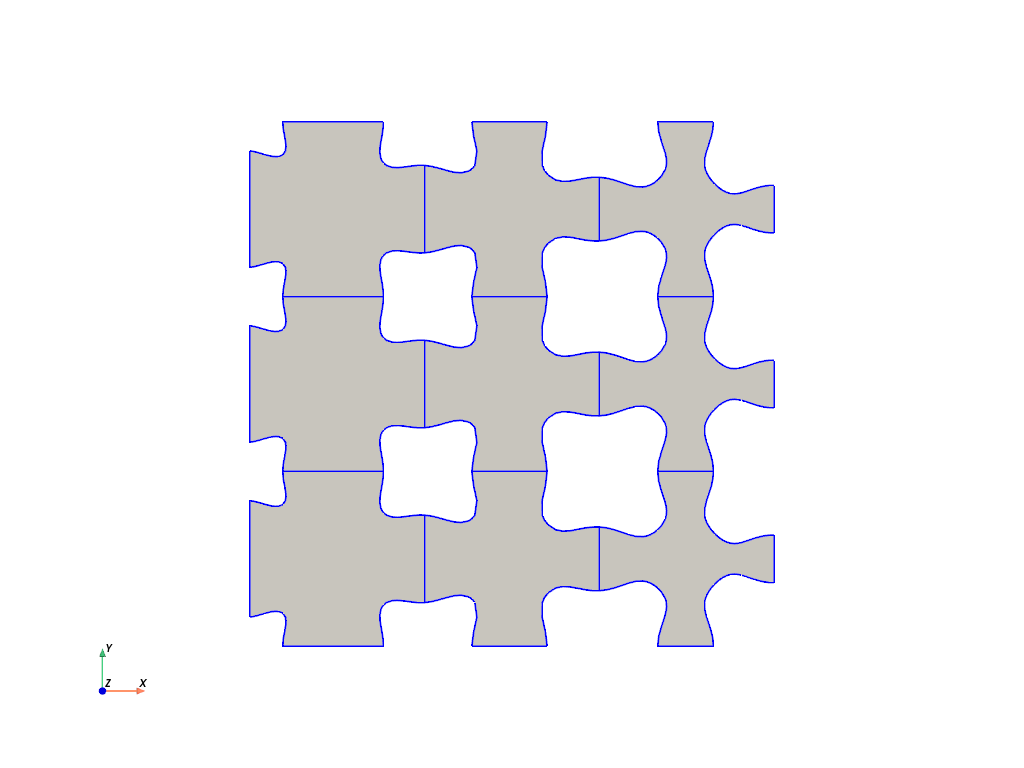

In [5]:
n = [3, 3]

spline_degree = 2

knots_x = [P0[0]] * spline_degree + list(np.linspace(P0[0], P1[0], n[0] + 1)) + [P1[0]] * spline_degree
knots_y = [P0[1]] * spline_degree + list(np.linspace(P0[1], P1[1], n[1] + 1)) + [P1[1]] * spline_degree

geometry_opts = {
    "basis_degree": 8,
    "spline_degree": spline_degree,
    "periodic": False,
}

geometry = SplineGeometry.interpolate_map(
    [knots_x, knots_y],
    mapping,
    gyroid.SchoenIWP().make_function(),
    geometry_opts,
)

geometry.coarse_mesh.set_parameter_field_from_function(parameter_function)

GlobalDofsManager.plot(geometry, communicators)

## 6) Initialize and run BDDC solver

Create the solver, set it up, and run the solution phase.

In [6]:
solver = BDDC(geometry, elasticity_pde, communicators, opts=opts)
solver.setup()
solver.solve()


Subdomains assembly.
Subdomains assembly: 11.1%
Subdomains assembly: 66.7%
Subdomains assembly: 100.0%
#### BDDC Solver ####

Number of subdomains: 9.
Number of global active dofs: 1150.

Number of iterations: 9.


Setup time:  8.453570235999905
Assemble time:  0.07546599300030721
Solve time:  0.0347639460001119
Total time:  8.563800175000324




## 7) Plot solution and stress

Visualize the displacement solution and the computed stress fields.

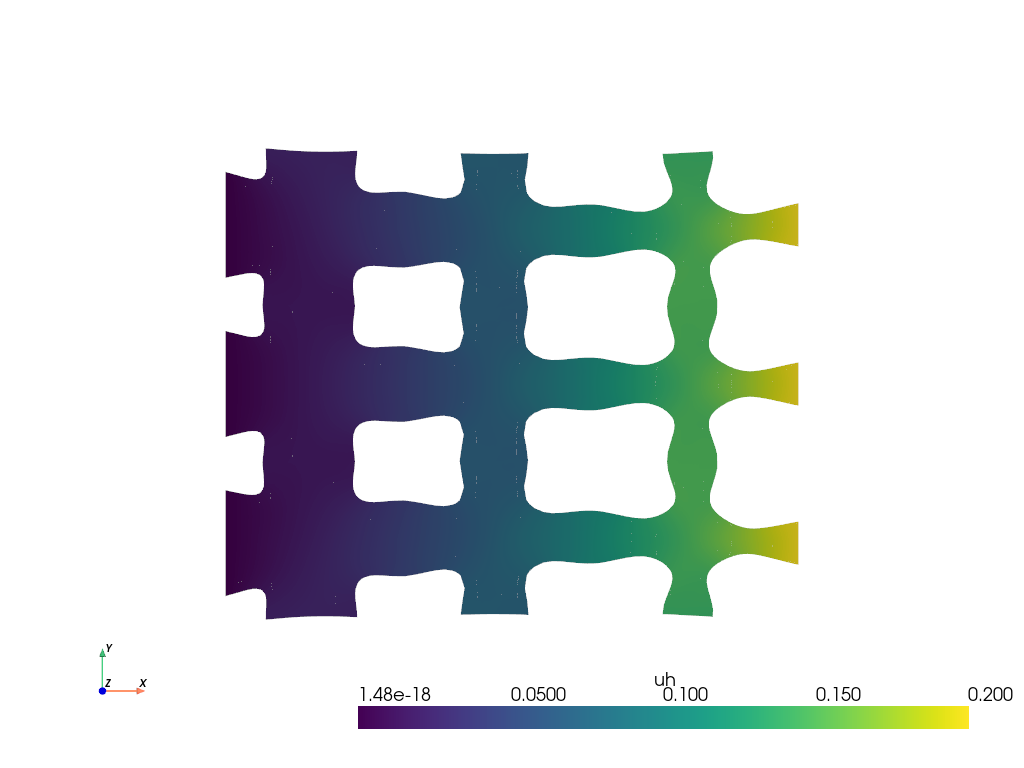

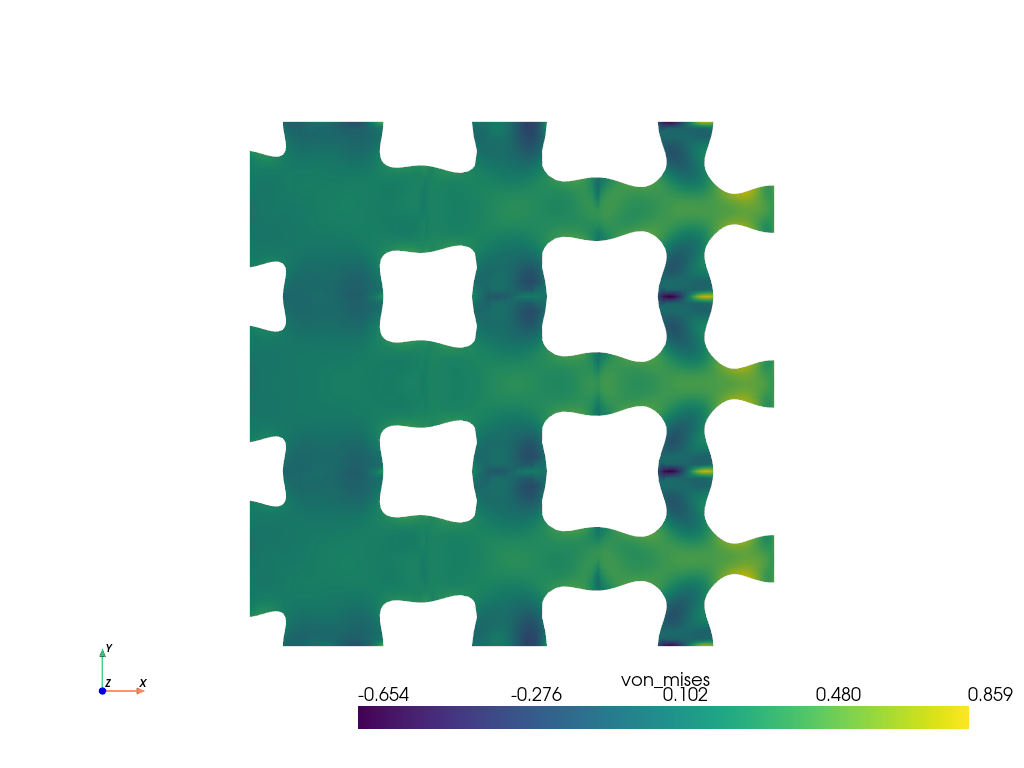

In [7]:
solver.plot_solution()
solver.plot_stress()